In [1]:
import pandas as pd, numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
from catboost import CatBoostRanker
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

print("ok")

ok


In [2]:
# -------------------------
# 1. データ読み込み & サンプリング
# -------------------------
transactions = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/transactions_train.csv")
customers = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/customers.csv")
articles = pd.read_csv("/Users/kurokawa/Desktop/kaggle/H&M/articles.csv")

print("transactions shape: ", transactions.shape)
print("customers shape: ", customers.shape)
print("articles shape: ", articles.shape)

articles.head()

transactions shape:  (31788324, 5)
customers shape:  (1371980, 7)
articles shape:  (105542, 25)


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulded, lightly padded cups that shape the bust and pro..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulded, lightly padded cups that shape the bust and pro..."


In [3]:
articles.columns

Index(['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc'],
      dtype='object')

In [8]:
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a91f8ca0d4b6efa8100
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93f4c830291c32bc3057
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6c9090f7dd3e38380dc
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c5feb1ca5dff07c43e,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c222539af5973a23ae6d
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe7fc0f26dd8d65a85a,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd4564743b005a805b1d


transactions shape:  (31788324, 5)
customers shape:  (1371980, 7)
articles shape:  (105542, 25)
Groupwise loss function. OneHotMaxSize set to 10
0:	total: 747ms	remaining: 3m 43s
50:	total: 31s	remaining: 2m 31s
100:	total: 1m 15s	remaining: 2m 29s
150:	total: 2m 6s	remaining: 2m 4s
200:	total: 3m 6s	remaining: 1m 31s
250:	total: 4m 4s	remaining: 47.7s
299:	total: 4m 59s	remaining: 0us


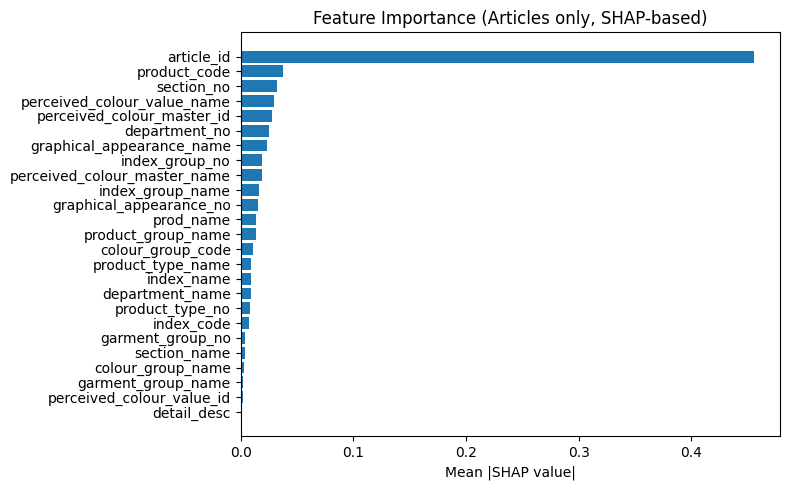

In [ ]:
import matplotlib.pyplot as plt
from catboost import CatBoostRanker, Pool  # グラフ描画とCatBoostのランク学習に必要なライブラリ

# -------------------------
# 1.5 正例・負例（1:5）ペア作成
# -------------------------
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])  # 日付型に変換

# 正例：2020-09-15以降に購入された customer_id × article_id のペア
positive = transactions[transactions['t_dat'] >= '2020-09-15'][['customer_id', 'article_id']].drop_duplicates()
positive['target'] = 1  # 正例のターゲットを 1 に設定

# 負例：正例と同じ顧客・商品集合からランダムに5倍サンプリング
np.random.seed(42)
neg = pd.DataFrame({
    'customer_id': np.random.choice(positive['customer_id'].unique(), size=len(positive)*5),
    'article_id': np.random.choice(positive['article_id'].unique(), size=len(positive)*5),
})
neg['target'] = 0  # 負例のターゲットを 0 に設定

# 正例と重複している組み合わせを除外（正例に含まれる customer_id × article_id は除く）
neg = neg[~neg.set_index(['customer_id', 'article_id']).index.isin(
    positive.set_index(['customer_id', 'article_id']).index
)]

# 正例と負例を結合し、学習用のデータフレームを作成
train_df = pd.concat([positive, neg], ignore_index=True)
train_df['group_id'] = train_df['customer_id']  # ランク学習用のグループIDとして customer_id を使う

# -------------------------
# 2. 商品側特徴量だけを使用
# -------------------------
articles_features = articles.copy()  # articles をコピー（マージのため）
train_df_articles_only = train_df[['customer_id', 'article_id', 'target']].copy()  # 必要な列だけ抽出

# 商品特徴量を article_id をキーにして結合
train_df_articles_only = train_df_articles_only.merge(articles_features, on='article_id', how='left')

# 使用する商品特徴量のリストを定義
feature_cols_articles_only = ['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc']

cat_cols_articles_only = feature_cols_articles_only  # カテゴリ列は全て上記の特徴量と同じ（CatBoostに文字列で渡す）

# customer_id順にソート（group_idの順序整備）し、インデックスを振り直す
train_df_articles_only = train_df_articles_only.sort_values('customer_id').reset_index(drop=True)

# カテゴリ列は文字列に変換し、欠損値を "missing" で補完
for col in cat_cols_articles_only:
    train_df_articles_only[col] = train_df_articles_only[col].astype(str).fillna("missing")

# CatBoost用の Pool を作成（特徴量・ターゲット・グループID・カテゴリ列を含める）
train_pool_articles_only = Pool(
    data=train_df_articles_only[feature_cols_articles_only],
    label=train_df_articles_only['target'],
    group_id=train_df_articles_only['customer_id'],
    cat_features=cat_cols_articles_only
)

# -------------------------
# 3. モデル学習（YetiRank）
# -------------------------
model_articles_only = CatBoostRanker(  # ランキングモデルのインスタンス
    iterations=300,                  # 学習ステップ数
    learning_rate=0.1,               # 学習率
    loss_function='YetiRank',        # 損失関数にYetiRankを指定
    eval_metric='NDCG',              # 評価指標にNDCG（ランキング向け）を使用
    verbose=50                       # 50イテレーションごとに進捗出力
)

model_articles_only.fit(train_pool_articles_only)  # モデル学習を実行

# -------------------------
# 4. SHAPベースの特徴量重要度を可視化
# -------------------------
# SHAP値を取得（全行×全特徴量、最初の列はbase valueなので除外）
shap_values = model_articles_only.get_feature_importance(train_pool_articles_only, type='ShapValues')[:, 1:]

# 各特徴量の平均絶対SHAP値を計算（= 重要度）
importances_mean = np.abs(shap_values).mean(axis=0)

# 可視化用のデータフレームに整形
importance_df = pd.DataFrame({
    'feature': feature_cols_articles_only,
    'importance': importances_mean
}).sort_values(by='importance', ascending=False)

# 特徴量重要度をグラフ描画
plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])  # 上位を上にするため[::-1]
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance (Articles only, SHAP-based)")
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------
# 5. 推薦スコアを出す（顧客×人気商品）
# -------------------------
from tqdm import tqdm

sample_submission = pd.read_csv('/Users/kurokawa/Desktop/kaggle/H&M/sample_submission.csv')
test_customers_all = sample_submission['customer_id'].unique()
popular_articles_100 = transactions['article_id'].value_counts().head(100).index.tolist()

batch_size = 3000  # 顧客3000人ずつ処理
results = []

for i in tqdm(range(0, len(test_customers_all), batch_size)):
    batch_customers = test_customers_all[i:i+batch_size]
    
    # 顧客×商品の直積を作成
    tmp = pd.DataFrame([(c, a) for c in batch_customers for a in popular_articles_100],
                       columns=['customer_id', 'article_id'])

    # 特徴量結合
    tmp = tmp.merge(articles_features, on='article_id', how='left')
    tmp['article_id'] = tmp['article_id'].astype(str).str.zfill(10)

    for col in cat_cols_articles_only:
        tmp[col] = tmp[col].astype(str).fillna("missing")

    tmp_pool = Pool(
        data=tmp[feature_cols_articles_only],
        cat_features=cat_cols_articles_only
    )

    tmp['score'] = model_articles_only.predict(tmp_pool)

    topk = tmp.sort_values(['customer_id', 'score'], ascending=[True, False]) \
              .groupby('customer_id')['article_id'] \
              .apply(lambda x: list(x.head(12))).reset_index()

    results.append(topk)

# 全バッチ結合
recommendations_df = pd.concat(results, ignore_index=True)

# 補完（12件未満対応）
popular_articles = [str(a).zfill(10) for a in transactions['article_id'].value_counts().head(500).index.tolist()]

def complete_12_articles(article_list):
    if len(article_list) >= 12:
        return article_list[:12]
    fill_items = [a for a in popular_articles if a not in article_list]
    return article_list + fill_items[:12 - len(article_list)]

recommendations_df['prediction'] = recommendations_df['article_id'].apply(complete_12_articles)
recommendations_df.drop(columns='article_id', inplace=True)
recommendations_df['prediction'] = recommendations_df['prediction'].apply(lambda x: ' '.join(x))

# 提出フォーマットに整形（不足顧客を補完）
submission_df = sample_submission[['customer_id']].merge(recommendations_df, on='customer_id', how='left')
fallback_12 = ' '.join(popular_articles[:12])
submission_df['prediction'] = submission_df['prediction'].fillna(fallback_12)

# 保存
submission_df.to_csv("articles_only_1st.csv", index=False)
print("✅ バッチ処理で安全に出力完了！")
print(submission_df.shape)


100%|██████████| 458/458 [09:29<00:00,  1.24s/it]


✅ バッチ処理で安全に出力完了！
(1371980, 2)


In [7]:
print(submission_df.shape)
print(sample_submission.shape)

(1371980, 2)
(1371980, 2)


In [11]:
results

[                                                           customer_id  \
 0     00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657   
 1     0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa   
 2     000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318   
 3     00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c5feb1ca5dff07c43e   
 4     00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe7fc0f26dd8d65a85a   
 ...                                                                ...   
 2995  008f552373e28d91f7a2c2d4a17c2c9c389e0c492ba97b01f5678e655830909c   
 2996  008f7660137471752fd969238359b246a6193f0d5715937c5b4ec356aa6b9c53   
 2997  008f76955f11ae0c0714fcae8a2d8809d6fe5a6d18ee9158b1a85bec72848c2e   
 2998  008f8bf13a12680e19545876cf7075143ec346d30a21d68130650038915a8172   
 2999  008f939ca8dbc336f3bd5c53a0a187127250590ffe42264f1e2d0020f5e59dc0   
 
                                                                                                ar

In [17]:
recommendations.head()

customer_id
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318    [0841383002, 0156231001, 0678942001, 0579541001, 0723469001, 0730683001, 0372860001, 0673396002,...
00039306476aaf41a07fed942884f16b30abfa83a2a8bea972019098d6406793    [0841383002, 0156231001, 0678942001, 0579541001, 0723469001, 0730683001, 0372860001, 0673396002,...
0003e867a930d0d6842f923d6ba7c9b77aba33fe2a0fbf4672f30b3e622fec55    [0841383002, 0156231001, 0678942001, 0579541001, 0723469001, 0730683001, 0372860001, 0673396002,...
00040239317e877c77ac6e79df42eb2633ad38fcac09fc0094e549180ddc201c    [0841383002, 0156231001, 0678942001, 0579541001, 0723469001, 0730683001, 0372860001, 0673396002,...
000493dd9fc463df1acc2081450c9e75ef8e87d5dd17ed6396773839f6bf71a9    [0841383002, 0156231001, 0678942001, 0579541001, 0723469001, 0730683001, 0372860001, 0673396002,...
Name: article_id, dtype: object

In [10]:
print(submission_df.shape)
submission_df.head()

(75481, 2)


,customer_id,prediction
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
1,00039306476aaf41a07fed942884f16b30abfa83a2a8bea972019098d6406793,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
2,0003e867a930d0d6842f923d6ba7c9b77aba33fe2a0fbf4672f30b3e622fec55,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
3,00040239317e877c77ac6e79df42eb2633ad38fcac09fc0094e549180ddc201c,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...
4,000493dd9fc463df1acc2081450c9e75ef8e87d5dd17ed6396773839f6bf71a9,0841383002 0156231001 0678942001 0579541001 0723469001 0730683001 0372860001 0673396002 06858130...


In [ ]:
duplicates_count_re = pd.Series(popular_articles).duplicated().sum()
print(f"重複している article_id の数: {duplicates_count_re}")

重複している article_id の数: 0


In [19]:
transactions['article_id'].value_counts().head(500)

article_id
706016001    50287
706016002    35043
372860001    31718
610776002    30199
759871002    26329
             ...  
832330002     4529
790096001     4529
742916002     4524
351484033     4520
507883014     4516
Name: count, Length: 500, dtype: int64

In [ ]:
# 商品の購入の計算

# 日付変換
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 直近と過去に分ける
recent = transactions[transactions['t_dat'] >= '2020-09-14']
past = transactions[transactions['t_dat'] < '2020-09-14']

# 出現回数カウント
recent_counts = recent['article_id'].value_counts()
past_counts = past['article_id'].value_counts()

# ランク変換（数が多いほど順位が高い → 1位が最大出現数）
recent_rank = recent_counts.rank(method='min', ascending=False).astype(int)
past_rank = past_counts.rank(method='min', ascending=False).astype(int)

# DataFrame に結合
rank_df = pd.DataFrame({
    'recent_rank': recent_rank,
    'past_rank': past_rank
}).dropna().astype(int)

# ✅ recent_rank が 1〜20位の article を抽出
top_recent_articles = rank_df[rank_df['recent_rank'] <= 20].sort_values('recent_rank')

# 結果表示
print(top_recent_articles)


            recent_rank  past_rank
article_id                        
924243001             1      14388
923758001             2      30323
918522001             3       8678
924243002             3      30608
751471001             5         24
909370001             6       5825
866731001             7       1083
865799006             8      11916
915529003             9       2444
448509014            10         20
915529005            11      28628
762846027            12      12849
714790020            13        153
918292001            14       1078
919273002            15      27719
850917001            16        139
896169005            17      19035
918525001            18      25960
894780001            19      18377
929275001            20      37577


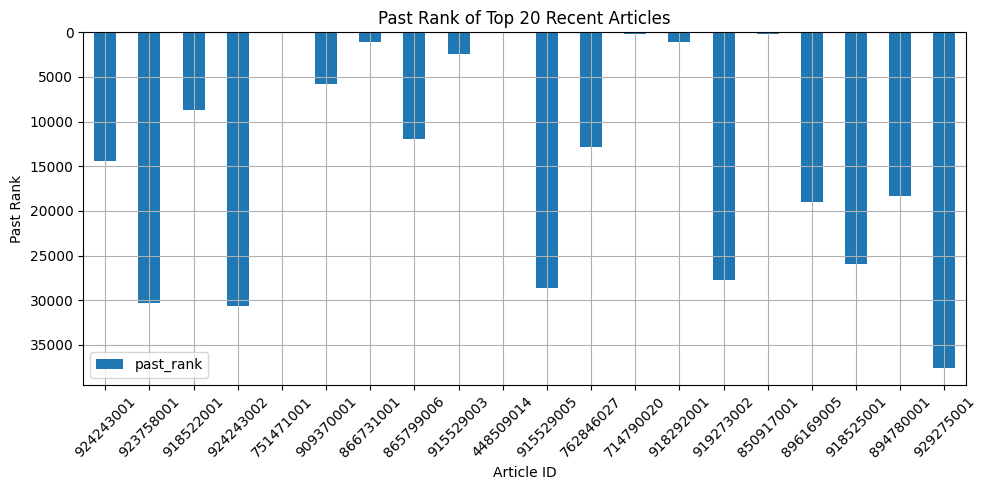

In [25]:
import matplotlib.pyplot as plt

top_recent_articles.plot(kind='bar', y=['past_rank'], figsize=(10, 5))
plt.title("Past Rank of Top 20 Recent Articles")
plt.xlabel("Article ID")
plt.ylabel("Past Rank")
plt.xticks(rotation=45)
plt.gca().invert_yaxis()  # ランク1位が上にくるように
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 直近1週間とそれ以前の商品の購入の割合ランキング比較

import pandas as pd
import matplotlib.pyplot as plt

# データ準備
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 分割
recent = transactions[transactions['t_dat'] >= '2020-09-14']
past = transactions[transactions['t_dat'] < '2020-09-14']

# articleごとの出現回数（件数）
recent_counts = recent['article_id'].value_counts()
past_counts = past['article_id'].value_counts()

# 全体に対する割合（構成比）を計算
recent_ratio = recent_counts / recent_counts.sum()
past_ratio = past_counts / past_counts.sum()

# 結合（両方にあるもの）
ratio_df = pd.DataFrame({
    'recent_ratio': recent_ratio,
    'past_ratio': past_ratio
}).dropna()

# 差分（割合の変化）を追加（正→人気上昇，負→人気低下）
ratio_df['ratio_diff'] = ratio_df['recent_ratio'] - ratio_df['past_ratio']

# 上昇した商品TOP10
top_up = ratio_df.sort_values('ratio_diff', ascending=False).head(10)

# 下降した商品TOP10
top_down = ratio_df.sort_values('ratio_diff', ascending=True).head(10)


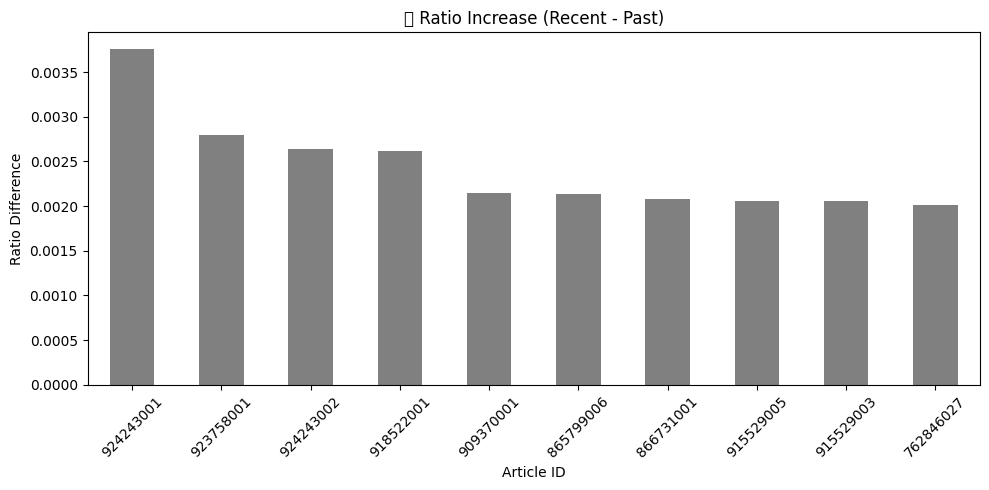

In [32]:
# 人気が上昇した商品TOP10を表示

plt.figure(figsize=(10, 5))
top_up['ratio_diff'].plot(kind='bar', color='gray')
plt.title("🔼 Ratio Increase (Recent - Past)")
plt.xlabel("Article ID")
plt.ylabel("Ratio Difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


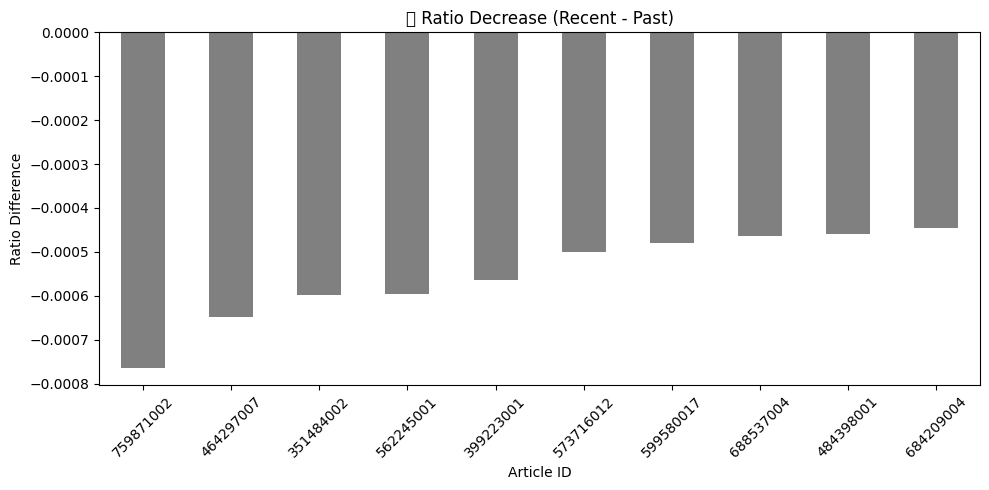

In [33]:
# 人気が減少した商品TOP10を表示

plt.figure(figsize=(10, 5))
top_down['ratio_diff'].plot(kind='bar', color='gray')
plt.title("🔽 Ratio Decrease (Recent - Past)")
plt.xlabel("Article ID")
plt.ylabel("Ratio Difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



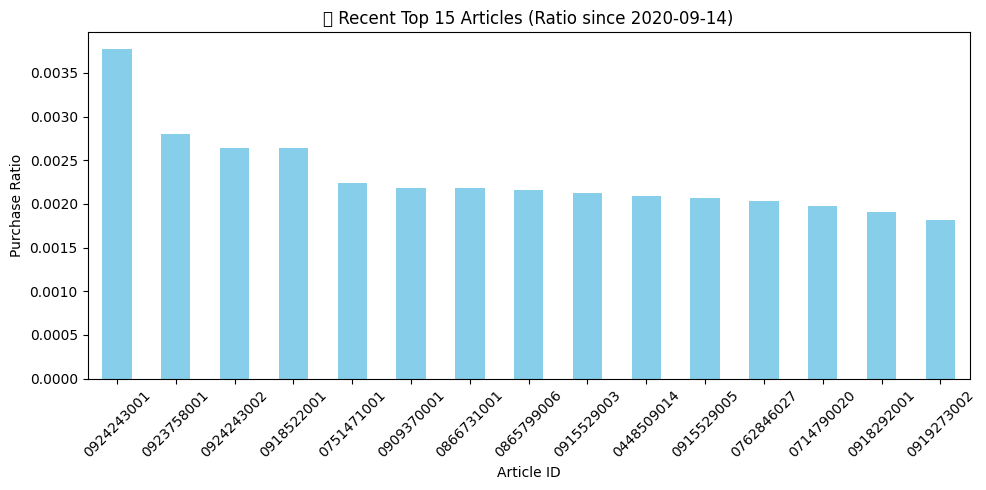

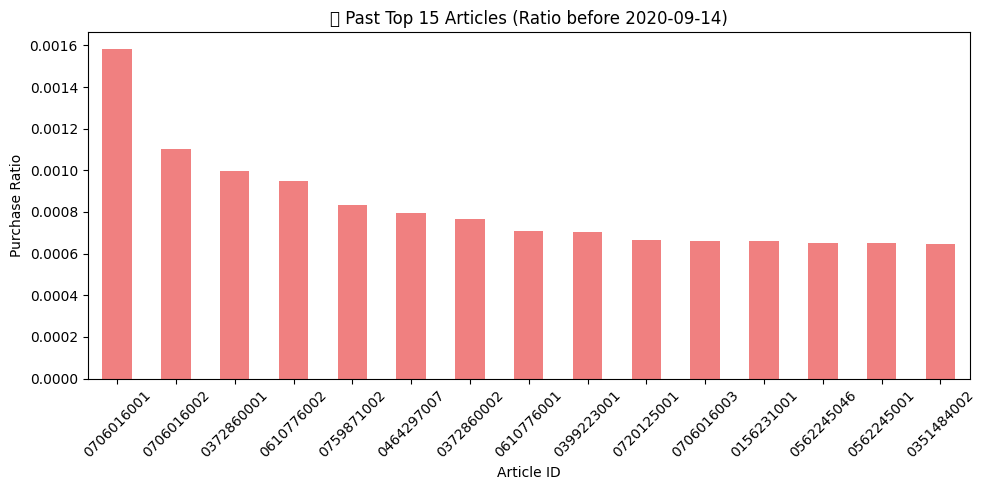

In [ ]:
# 年齢層を考慮せずに

import pandas as pd
import matplotlib.pyplot as plt

# 日付を変換（必要に応じて）
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 直近と過去に分割
recent = transactions[transactions['t_dat'] >= '2020-09-14']
past = transactions[transactions['t_dat'] < '2020-09-14']

# 出現割合（各articleの割合）
recent_ratio = recent['article_id'].value_counts(normalize=True)
past_ratio = past['article_id'].value_counts(normalize=True)

# 上位15件を抽出（期間内の割合が高い順）
top15_recent = recent_ratio.head(15)
top15_past = past_ratio.head(15)

# 文字列でゼロ埋め（商品ID 10桁）
top15_recent.index = top15_recent.index.astype(str).str.zfill(10)
top15_past.index = top15_past.index.astype(str).str.zfill(10)

# グラフ描画：最近（直近1週間）
plt.figure(figsize=(10, 5))
top15_recent.plot(kind='bar', color='skyblue')
plt.title("📈 Recent Top 15 Articles (Ratio since 2020-09-14)")
plt.ylabel("Purchase Ratio")
plt.xlabel("Article ID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# グラフ描画：過去（それ以前）
plt.figure(figsize=(10, 5))
top15_past.plot(kind='bar', color='lightcoral')
plt.title("📉 Past Top 15 Articles (Ratio before 2020-09-14)")
plt.ylabel("Purchase Ratio")
plt.xlabel("Article ID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# 年齢層を考慮せずに

# 日付をdatetime型に変換
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 直近とそれ以前で分割
recent = transactions[transactions['t_dat'] >= '2020-09-14']
past = transactions[transactions['t_dat'] < '2020-09-14']

# 各期間の上位15記事を取得
top15_recent = recent['article_id'].value_counts().head(15).index.tolist()
top15_past = past['article_id'].value_counts().head(15).index.tolist()

# 記事マスタと結合（ジャンル情報取得）
top_recent_info = articles[articles['article_id'].isin(top15_recent)][
    ['article_id', 'product_type_name', 'product_group_name']
].copy()
top_past_info = articles[articles['article_id'].isin(top15_past)][
    ['article_id', 'product_type_name', 'product_group_name']
].copy()

# ランク付け
top_recent_info['rank'] = [f'R{i+1}' for i in range(len(top_recent_info))]
top_past_info['rank'] = [f'R{i+1}' for i in range(len(top_past_info))]

# 表示
print("📈 直近の人気商品ジャンル（2020-09-14以降）:")
display(top_recent_info)

print("\n📉 過去の人気商品ジャンル（2020-09-14以前）:")
display(top_past_info)


📈 直近の人気商品ジャンル（2020-09-14以降）:


,article_id,product_type_name,product_group_name,rank
3091,448509014,Trousers,Garment Lower body,R1
56694,714790020,Trousers,Garment Lower body,R2
67522,751471001,Trousers,Garment Lower body,R3
71107,762846027,Shirt,Garment Upper body,R4
95217,865799006,Trousers,Garment Lower body,R5
95499,866731001,Leggings/Tights,Garment Lower body,R6
103108,909370001,Dress,Garment Full body,R7
103796,915529003,Sweater,Garment Upper body,R8
103797,915529005,Sweater,Garment Upper body,R9
104045,918292001,Leggings/Tights,Garment Lower body,R10



📉 過去の人気商品ジャンル（2020-09-14以前）:


,article_id,product_type_name,product_group_name,rank
67,156231001,Underwear Tights,Socks & Tights,R1
1469,351484002,Swimwear bottom,Swimwear,R2
1713,372860001,Socks,Socks & Tights,R3
1714,372860002,Socks,Socks & Tights,R4
2236,399223001,Trousers,Garment Lower body,R5
3711,464297007,Underwear bottom,Underwear,R6
14240,562245001,Trousers,Garment Lower body,R7
14253,562245046,Trousers,Garment Lower body,R8
24836,610776001,T-shirt,Garment Upper body,R9
24837,610776002,T-shirt,Garment Upper body,R10


In [36]:
# 直近1週間の購入数合計（分母）
recent_total = recent.shape[0]

# 最も購入された商品（分子）
top_article = recent['article_id'].value_counts().iloc[0]

# 割合を計算
ratio = top_article / recent_total
print(f"Top article ratio: {ratio:.4%}")
print(top_article)
print(recent_total)


Top article ratio: 0.3777%
1119
296305


In [42]:
import pandas as pd

# 1. 日付をdatetime型に変換
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 2. 顧客情報から年齢層を3つに分割（~30歳, 31-60歳, 61歳~）
customers['age_group3'] = pd.cut(
    customers['age'],
    bins=[0, 30, 60, 200],
    labels=['~30', '31-60', '60~']
)

# 3. transactionsに年齢層を結合
transactions = transactions.merge(customers[['customer_id', 'age_group3']], on='customer_id', how='left')

# 4. 直近1週間とそれ以前に分割
recent = transactions[transactions['t_dat'] >= '2020-09-14']
past = transactions[transactions['t_dat'] < '2020-09-14']

# 5. 年齢層 × 期間ごとの article_id 出現回数をカウント → ランキングに変換（15位まで）
def get_top15_articles(df, label):
    return (
        df.groupby('age_group3')['article_id']
        .value_counts()
        .groupby(level=0)
        .head(15)
        .reset_index(name='purchase_count')
        .assign(period=label)
    )

top15_recent = get_top15_articles(recent, 'recent')
top15_past = get_top15_articles(past, 'past')

# 6. 結合して比較可能に
top15_combined = pd.concat([top15_recent, top15_past], axis=0).reset_index(drop=True)

# 7. 結果表示（確認用）
for age_group in ['~30', '31-60', '60~']:
    print(f"\n🧒 年齢層: {age_group}")
    display(top15_combined[top15_combined['age_group3'] == age_group])



🧒 年齢層: ~30


,age_group3,article_id,purchase_count,period
0,~30,924243001,571,recent
1,~30,918522001,485,recent
2,~30,866731001,451,recent
3,~30,923758001,424,recent
4,~30,448509014,423,recent
5,~30,909370001,410,recent
6,~30,924243002,409,recent
7,~30,915529005,395,recent
8,~30,918292001,393,recent
9,~30,865799006,372,recent



🧒 年齢層: 31-60


,age_group3,article_id,purchase_count,period
15,31-60,924243001,455,recent
16,31-60,923758001,376,recent
17,31-60,924243002,317,recent
18,31-60,751471001,312,recent
19,31-60,915529003,267,recent
20,31-60,928206001,264,recent
21,31-60,919273002,263,recent
22,31-60,910601003,261,recent
23,31-60,762846027,248,recent
24,31-60,918522001,246,recent



🧒 年齢層: 60~


,age_group3,article_id,purchase_count,period
30,60~,930380001,93,recent
31,60~,924243001,90,recent
32,60~,865799006,64,recent
33,60~,751471043,59,recent
34,60~,924243002,56,recent
35,60~,918522001,52,recent
36,60~,910601003,47,recent
37,60~,579541001,35,recent
38,60~,751471001,34,recent
39,60~,896169002,33,recent


In [45]:
# 1. 各期間ごとの総購入数（年齢層ごと）
recent_total = recent.groupby('age_group3').size().rename('total')
past_total = past.groupby('age_group3').size().rename('total')

# 2. 上位15商品（割合ベース）の抽出関数
def get_top15_ratio(df, label, total_counts):
    # 商品ごとの出現数をカウント
    counts = (
        df.groupby('age_group3')['article_id']
        .value_counts()
        .groupby(level=0)
        .head(15)
        .reset_index(name='purchase_count')
    )
    # 総購入数と結合
    counts = counts.merge(total_counts, on='age_group3', how='left')
    # 割合計算（%）
    counts['purchase_ratio'] = counts['purchase_count'] / counts['total'] * 100
    counts = counts.drop(columns='total')
    counts['period'] = label
    return counts

# 3. 年齢層ごとに割合を計算（recent / past）
top15_recent_ratio = get_top15_ratio(recent, 'recent', recent_total)
top15_past_ratio = get_top15_ratio(past, 'past', past_total)

# 4. 結合＆ジャンル情報追加
top15_combined_ratio = pd.concat([top15_recent_ratio, top15_past_ratio], axis=0).reset_index(drop=True)
top15_combined_ratio = top15_combined_ratio.merge(
    articles[['article_id', 'product_type_name', 'product_group_name']],
    on='article_id',
    how='left'
)

# 5. 表示
for age_group in ['~30', '31-60', '60~']:
    print(f"\n👤 年齢層: {age_group}（商品購入割合ランキング）")
    display(
        top15_combined_ratio[top15_combined_ratio['age_group3'] == age_group]
        .sort_values(['period', 'purchase_ratio'], ascending=[True, False])
        .reset_index(drop=True)
    )



👤 年齢層: ~30（商品購入割合ランキング）


,age_group3,article_id,purchase_count,purchase_ratio,period,product_type_name,product_group_name
0,~30,706016001,31419,0.212525,past,Trousers,Garment Lower body
1,~30,706016002,20908,0.141426,past,Trousers,Garment Lower body
2,~30,759871002,18595,0.125781,past,Vest top,Garment Upper body
3,~30,372860001,17618,0.119172,past,Socks,Socks & Tights
4,~30,464297007,15653,0.105880,past,Underwear bottom,Underwear
5,~30,156231001,15043,0.101754,past,Underwear Tights,Socks & Tights
6,~30,610776002,14989,0.101389,past,T-shirt,Garment Upper body
7,~30,448509014,12830,0.086785,past,Trousers,Garment Lower body
8,~30,372860002,12781,0.086454,past,Socks,Socks & Tights
9,~30,399223001,12741,0.086183,past,Trousers,Garment Lower body



👤 年齢層: 31-60（商品購入割合ランキング）


,age_group3,article_id,purchase_count,purchase_ratio,period,product_type_name,product_group_name
0,31-60,706016001,17508,0.113757,past,Trousers,Garment Lower body
1,31-60,610776002,13747,0.089320,past,T-shirt,Garment Upper body
2,31-60,372860001,13207,0.085811,past,Socks,Socks & Tights
3,31-60,706016002,13022,0.084609,past,Trousers,Garment Lower body
4,31-60,372860002,10887,0.070737,past,Socks,Socks & Tights
5,31-60,562245001,10714,0.069613,past,Trousers,Garment Lower body
6,31-60,399256001,10615,0.068970,past,Trousers,Garment Lower body
7,31-60,568601006,10603,0.068892,past,Blazer,Garment Upper body
8,31-60,608776002,10124,0.065780,past,Socks,Socks & Tights
9,31-60,610776001,9736,0.063259,past,T-shirt,Garment Upper body



👤 年齢層: 60~（商品購入割合ランキング）


,age_group3,article_id,purchase_count,purchase_ratio,period,product_type_name,product_group_name
0,60~,579541001,1478,0.125418,past,Cardigan,Garment Upper body
1,60~,399256005,1379,0.117017,past,Trousers,Garment Lower body
2,60~,399256001,1140,0.096736,past,Trousers,Garment Lower body
3,60~,610776001,1132,0.096057,past,T-shirt,Garment Upper body
4,60~,610776002,1054,0.089439,past,T-shirt,Garment Upper body
5,60~,678942001,1003,0.085111,past,Top,Garment Upper body
6,60~,796210010,955,0.081038,past,Trousers,Garment Lower body
7,60~,673677002,940,0.079765,past,Sweater,Garment Upper body
8,60~,573716012,916,0.077728,past,Trousers,Garment Lower body
9,60~,783346001,873,0.074080,past,Trousers,Garment Lower body


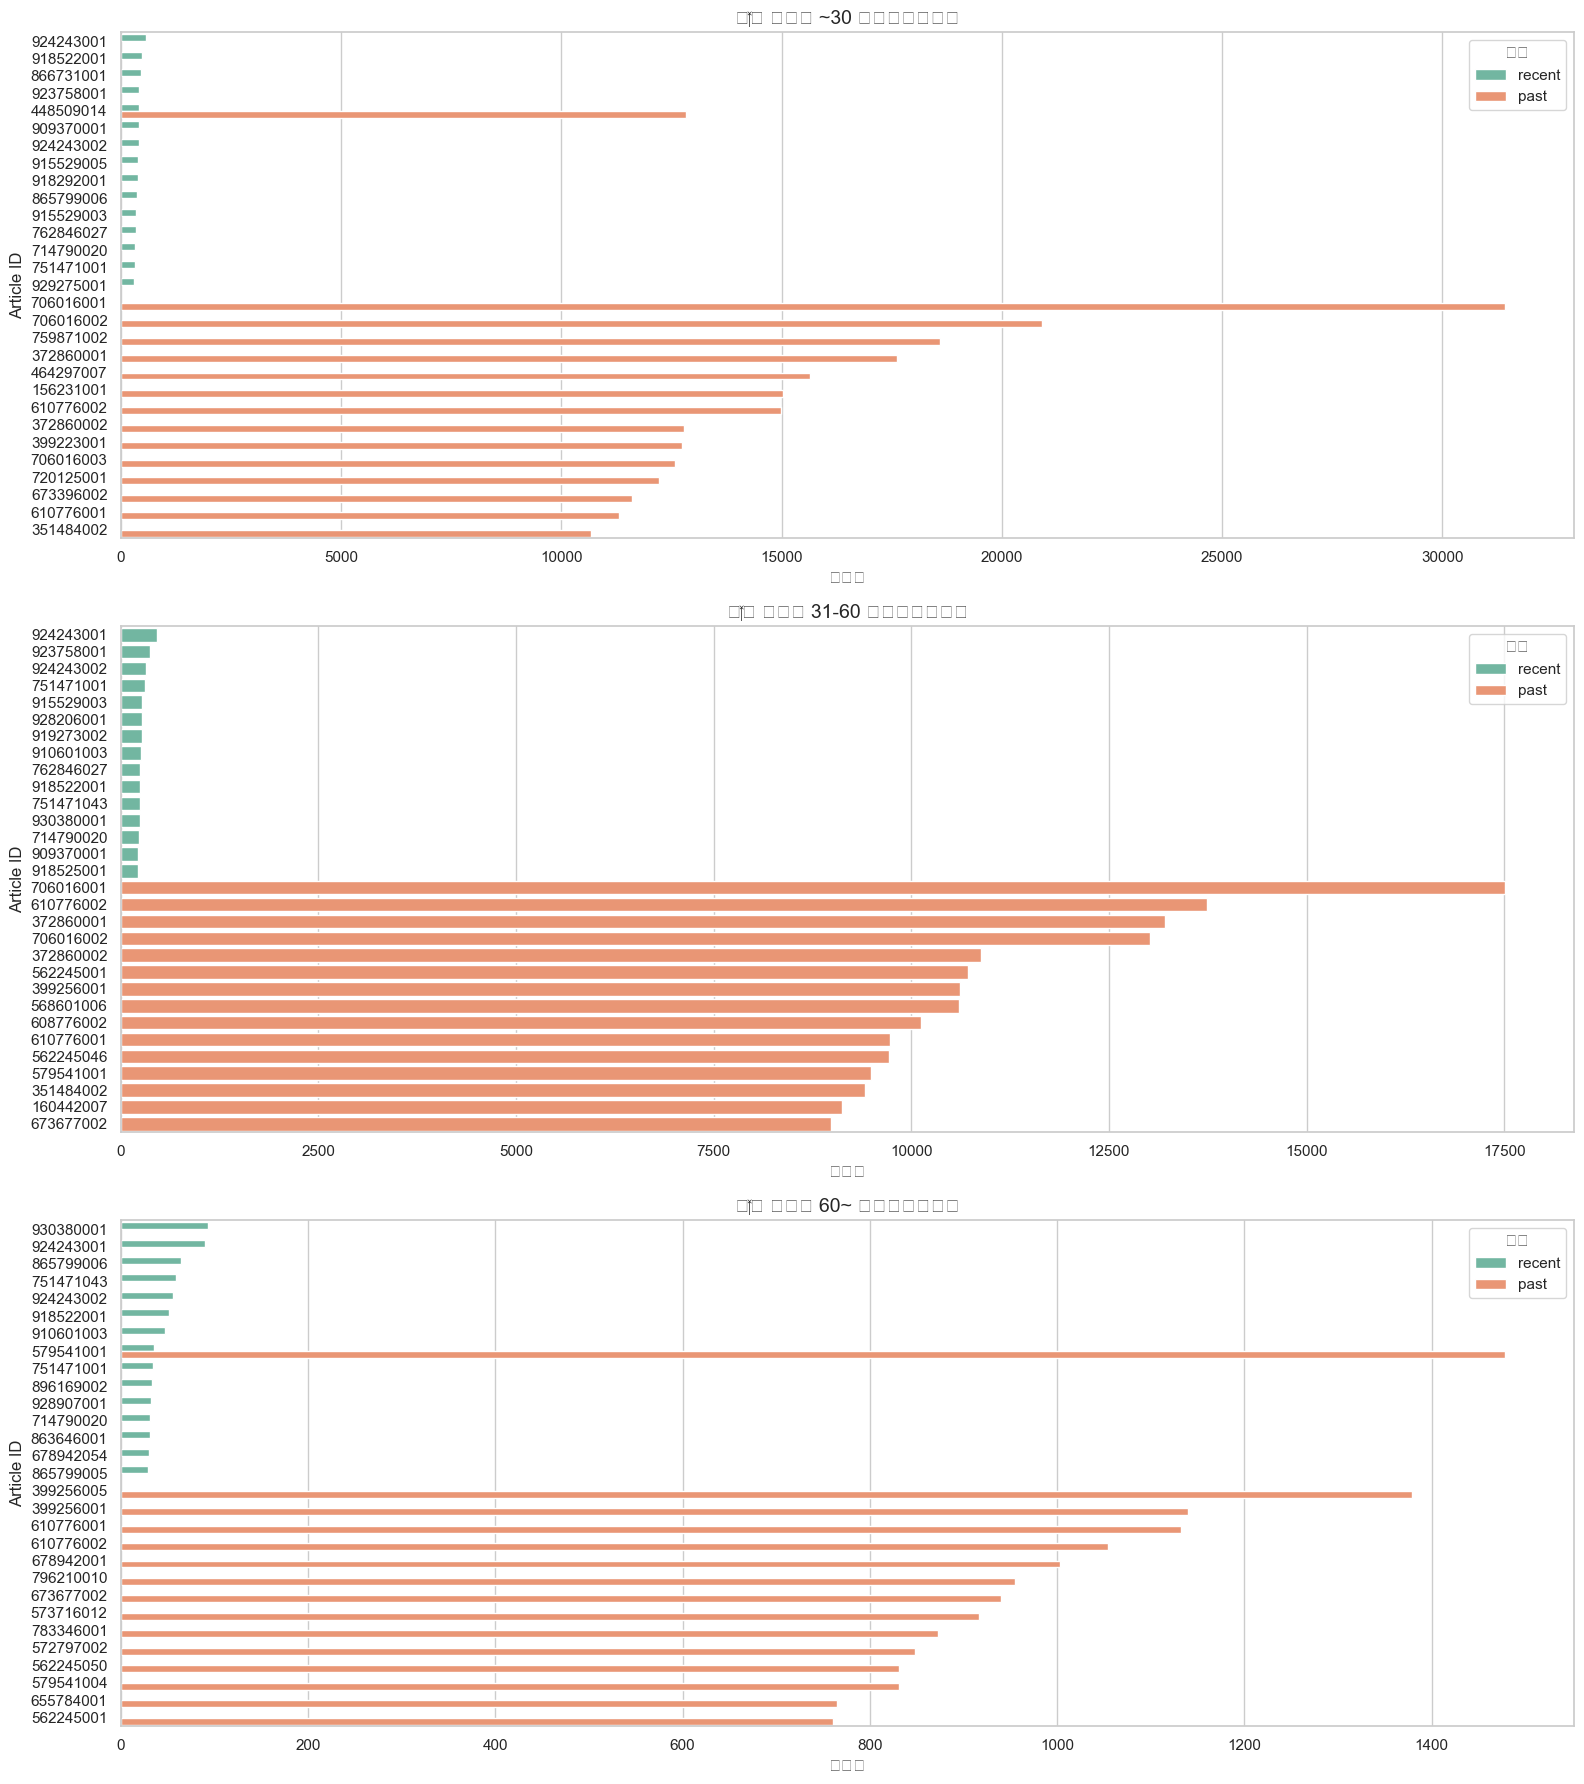

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# 可視化スタイル設定
sns.set(style="whitegrid")
plt.figure(figsize=(16, 18))

# 年齢層ごとにサブプロットを作成
age_groups = ['~30', '31-60', '60~']
for idx, age_group in enumerate(age_groups, 1):
    plt.subplot(3, 1, idx)

    # 対象データ
    plot_df = top15_combined[top15_combined['age_group3'] == age_group].copy()

    # article_id を文字列にして横軸ラベルを見やすくする
    plot_df['article_id'] = plot_df['article_id'].astype(str)

    # 棒グラフ描画
    sns.barplot(
        data=plot_df,
        x='purchase_count',
        y='article_id',
        hue='period',
        palette='Set2'
    )

    plt.title(f'🧑‍🎨 年齢層 {age_group} の人気商品比較', fontsize=14)
    plt.xlabel('購入数')
    plt.ylabel('Article ID')
    plt.legend(title='期間')

plt.tight_layout()
plt.show()


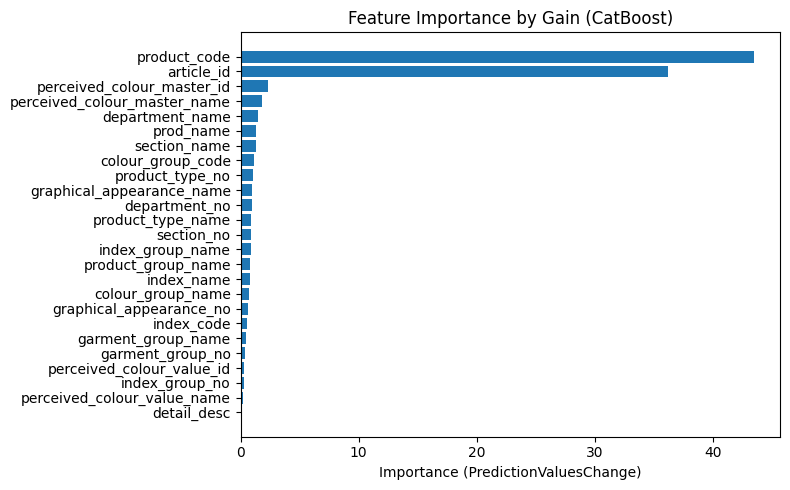

In [10]:
# gain（PredictionValuesChange）で重要度を取得
gain_importance = model_articles_only.get_feature_importance(
    train_pool_articles_only,
    type='PredictionValuesChange'
)

gain_df = pd.DataFrame({
    'feature': feature_cols_articles_only,
    'importance': gain_importance
}).sort_values(by='importance', ascending=False)

# 可視化
plt.figure(figsize=(8, 5))
plt.barh(gain_df['feature'][::-1], gain_df['importance'][::-1])
plt.xlabel("Importance (PredictionValuesChange)")
plt.title("Feature Importance by Gain (CatBoost)")
plt.tight_layout()
plt.show()


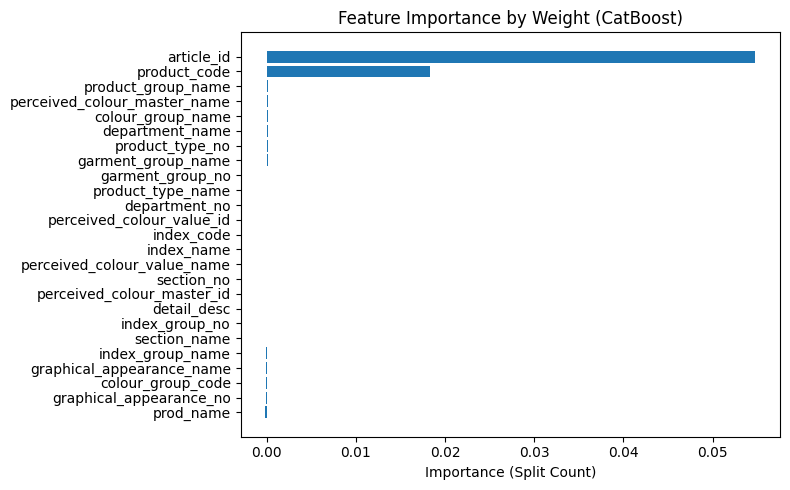

In [11]:
# weight（FeatureImportance）で重要度を取得
weight_importance = model_articles_only.get_feature_importance(
    train_pool_articles_only,
    type='FeatureImportance'
)

weight_df = pd.DataFrame({
    'feature': feature_cols_articles_only,
    'importance': weight_importance
}).sort_values(by='importance', ascending=False)

# 可視化
plt.figure(figsize=(8, 5))
plt.barh(weight_df['feature'][::-1], weight_df['importance'][::-1])
plt.xlabel("Importance (Split Count)")
plt.title("Feature Importance by Weight (CatBoost)")
plt.tight_layout()
plt.show()


In [ ]:
# articlesに関しては，gain も weight も product_code と article_id が高い
# →catboostRankerでは顧客がどの商品を好むかのスコアを算出している．

# 12個未満の時の埋めるアルゴリズムの確認

In [ ]:
popular_articles

['0706016001',
 '0706016002',
 '0372860001',
 '0610776002',
 '0759871002',
 '0464297007',
 '0372860002',
 '0610776001',
 '0399223001',
 '0706016003',
 '0720125001',
 '0156231001',
 '0562245046',
 '0562245001',
 '0351484002',
 '0399256001',
 '0673396002',
 '0568601006',
 '0448509014',
 '0673677002',
 '0751471001',
 '0608776002',
 '0160442007',
 '0688537004',
 '0573716012',
 '0158340001',
 '0590928001',
 '0579541001',
 '0706016015',
 '0554450001',
 '0599580017',
 '0484398001',
 '0507909001',
 '0160442010',
 '0562245018',
 '0741356002',
 '0684209004',
 '0111586001',
 '0636323001',
 '0111593001',
 '0572797001',
 '0783346001',
 '0565379001',
 '0717490008',
 '0228257001',
 '0749699002',
 '0706016006',
 '0688537011',
 '0399256005',
 '0678942001',
 '0759871001',
 '0600886001',
 '0695632002',
 '0572797002',
 '0711053003',
 '0537116001',
 '0179123001',
 '0749699001',
 '0685814001',
 '0684209013',
 '0536139006',
 '0841383002',
 '0719655001',
 '0723469001',
 '0778064003',
 '0507910001',
 '01087750

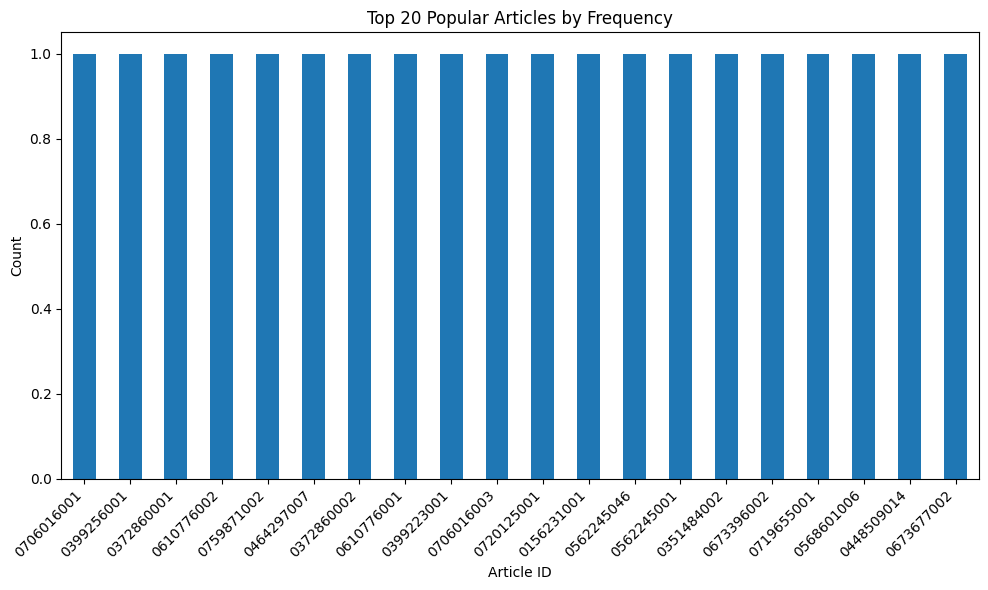

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 例：popular_articles が article_id のリストとして与えられているとする
# popular_articles = ['1234567890', '1234567890', '1111111111', ...]

# DataFrame に変換して出現回数を集計
article_counts = pd.Series(popular_articles).value_counts().sort_values(ascending=False)

# 上位20件だけ可視化（多すぎると見にくいため）
top_articles = article_counts.head(20)

# 棒グラフを描画
plt.figure(figsize=(10, 6))
top_articles.plot(kind='bar')
plt.title("Top 20 Popular Articles by Frequency")
plt.xlabel("Article ID")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 年齢毎に直近1週間で上位の商品を12個未満の場合に追加するコード

In [ ]:
# --- 年齢層 × 直近人気商品ランキングの辞書作成 ---
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
customers['age_group3'] = pd.cut(customers['age'], bins=[0, 30, 60, 200], labels=['~30', '31-60', '60~'])
transactions = transactions.merge(customers[['customer_id', 'age_group3']], on='customer_id', how='left')

recent = transactions[transactions['t_dat'] >= '2020-09-14']
top_items_by_age = (
    recent.groupby('age_group3')['article_id']
    .value_counts()
    .groupby(level=0)
    .head(50)
    .reset_index()
    .rename(columns={'article_id': 'article_id_raw'})
)
top_items_by_age['article_id'] = top_items_by_age['article_id_raw'].astype(str).str.zfill(10)
age_group_popular_dict = top_items_by_age.groupby('age_group3')['article_id'].apply(list).to_dict()
